In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

RANDOM_SEED = 42

## EDA

In [3]:
df = pd.read_csv('historical_data.csv')

df.head()

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


In [4]:
print("Antal rader:", df.shape[0])
print("Antal kolumner:", df.shape[1])

print("\nDatasetets datatyper:")
print("------------------------------")
print(df.dtypes)

Antal rader: 12000
Antal kolumner: 18

Datasetets datatyper:
------------------------------
id                              int64
day                             int64
event_type                        str
category                          str
region                            str
device                            str
account_age_days              float64
num_prev_listings               int64
prev_reports_30d                int64
verification_level              int64
price                         float64
num_images                      int64
message_length                  int64
contains_off_platform           int64
urgency_words                   int64
payment_attempt                 int64
time_to_first_response_min    float64
is_suspicious                   int64
dtype: object


In [5]:
print("\nSaknade värden per kolumn:")
print("------------------------------")
print(df.isna().sum())


Saknade värden per kolumn:
------------------------------
id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64


In [6]:
df = df.drop(columns=['id'])

df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,12000.0,7.482667,4.032520,1.00,4.000,7.000,11.000,14.00
account_age_days,12000.0,99.632567,112.903541,2.20,36.300,66.600,120.700,2741.70
num_prev_listings,12000.0,3.027750,1.766467,0.00,2.000,3.000,4.000,12.00
prev_reports_30d,12000.0,0.151500,0.386083,0.00,0.000,0.000,0.000,3.00
verification_level,12000.0,0.710167,0.719171,0.00,0.000,1.000,1.000,2.00
price,11182.0,207.348603,196.226023,7.67,86.195,149.225,256.795,2743.08
num_images,12000.0,2.870417,1.766886,0.00,2.000,3.000,4.000,10.00
message_length,12000.0,111.154417,66.396885,0.00,63.000,108.000,155.000,416.00
contains_off_platform,12000.0,0.072833,0.259874,0.00,0.000,0.000,0.000,1.00
urgency_words,12000.0,0.099083,0.298786,0.00,0.000,0.000,0.000,1.00


In [7]:
print("Target-fördelning:")
print(df["is_suspicious"].value_counts())

print("\nProcentuell fördelning:")
print(df["is_suspicious"].value_counts(normalize=True) * 100)

Target-fördelning:
is_suspicious
0    10776
1     1224
Name: count, dtype: int64

Procentuell fördelning:
is_suspicious
0    89.8
1    10.2
Name: proportion, dtype: float64


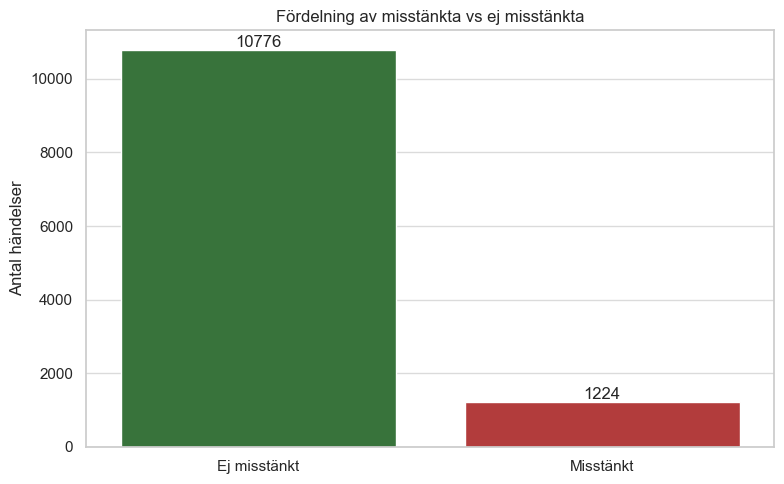

In [8]:
counts = df["is_suspicious"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
ax = sns.countplot(x="is_suspicious", hue="is_suspicious", data=df, palette=["#2E7D32", "#C62828"], legend=False)
plt.title("Fördelning av misstänkta vs ej misstänkta")
plt.xlabel("")
plt.ylabel("Antal händelser")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Ej misstänkt", "Misstänkt"])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.grid(True, axis="y", alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
numeric_cols = df.select_dtypes(include=np.number)
correlations = numeric_cols.corr()["is_suspicious"].sort_values(ascending=False)

top_corr = correlations.drop("is_suspicious")

top_corr = top_corr.reindex(top_corr.abs().sort_values(ascending=False).index)
top_5 = top_corr.head(5)

print("Korrelation med is_suspicious:")
print("----------------------------------")
print(top_5)

Korrelation med is_suspicious:
----------------------------------
contains_off_platform    0.141828
prev_reports_30d         0.130920
account_age_days        -0.103146
verification_level      -0.100409
urgency_words            0.087295
Name: is_suspicious, dtype: float64


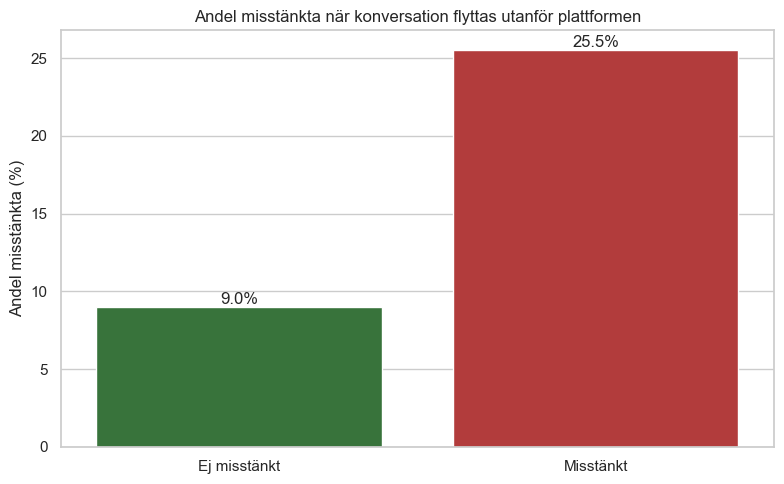

In [10]:
cross_tab = pd.crosstab(
    df["contains_off_platform"],
    df["is_suspicious"],
    normalize="index"
) * 100

risk_percent = cross_tab[1]

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=risk_percent.index, hue=risk_percent.index,
    y=risk_percent.values, palette=["#2E7D32", "#C62828"], legend=False
)

plt.title("Andel misstänkta när konversation flyttas utanför plattformen")
plt.xlabel("")
plt.ylabel("Andel misstänkta (%)")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Ej misstänkt", "Misstänkt"])

for i, v in enumerate(risk_percent.values):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Insikter
- Modellen/policyn ska fokusera på en minoritet med hög risk då datasetet är obalanserat.  
- Risken är mycket högre när användaren försöker flytta konversationen utanför plattformen (25.5%). Detta är en tydlig signal som kan användas för prioritering. 

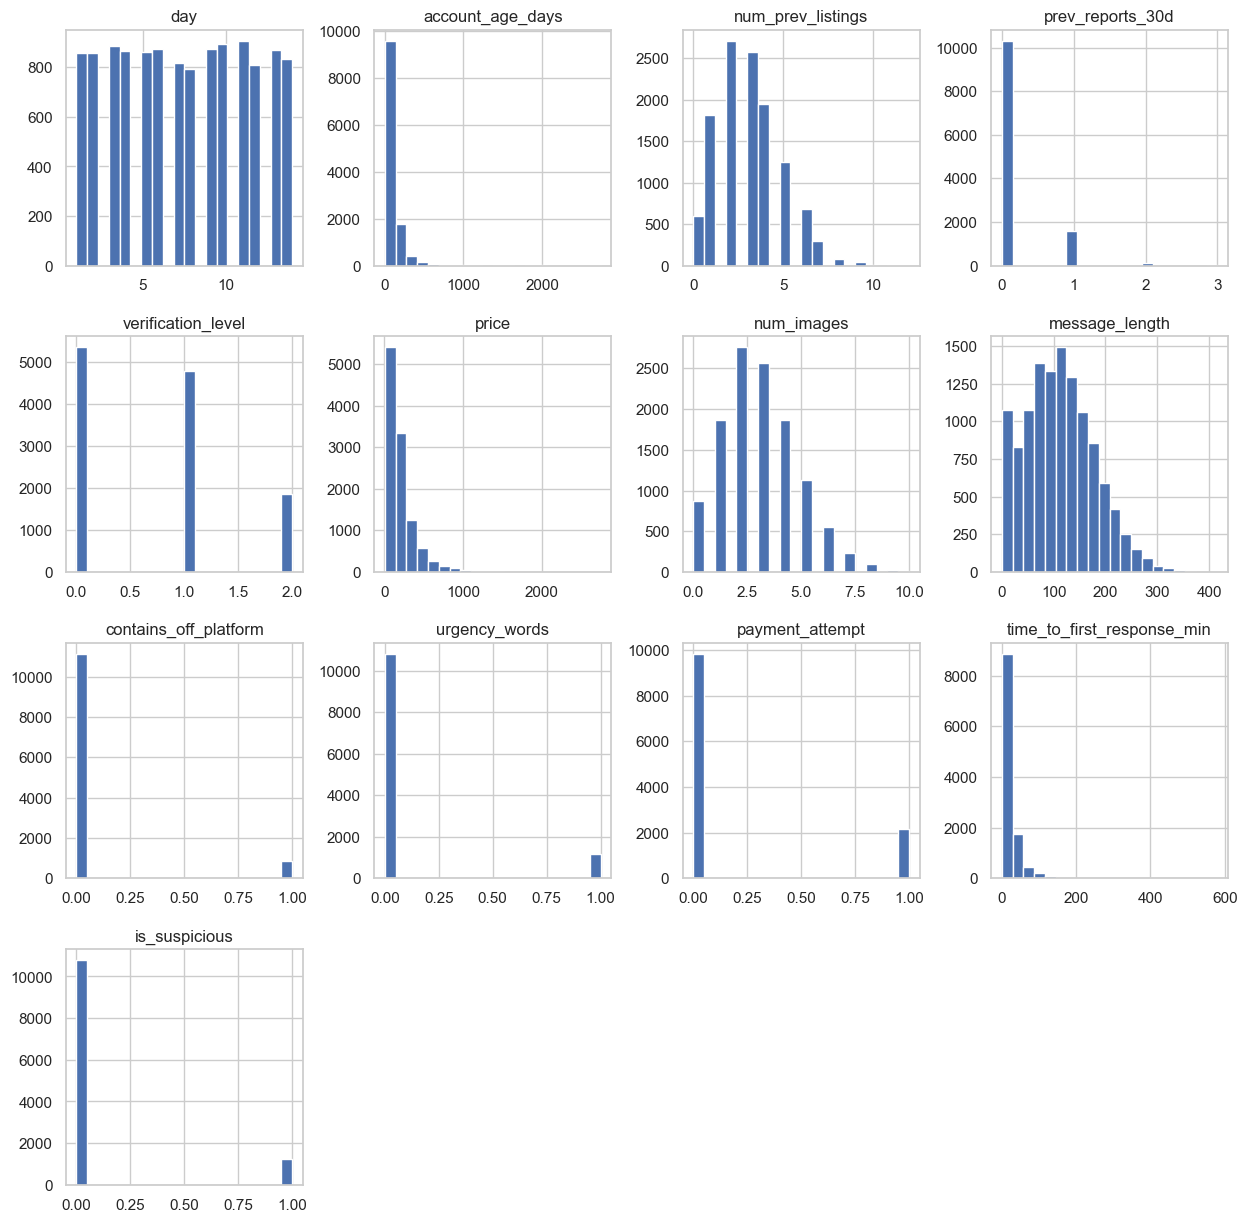

In [11]:
df.hist(figsize=(15,15), bins=20)
plt.show()

Split data

In [12]:
X = df.drop(columns=['is_suspicious'])
y = df['is_suspicious'].copy()

# Använd för K-fold eller cross validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state= RANDOM_SEED,
    stratify=y
)

# Använd om inte K-fold eller cross validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state= RANDOM_SEED,
    stratify= y_train
)

Pipeline

In [13]:
num_cols = ['day',
            'account_age_days',
            'num_prev_listings',
            'prev_reports_30d',
            'verification_level',
            'price', 'num_images',
            'message_length',
            'contains_off_platform',
            'urgency_words',
            'payment_attempt',
            'time_to_first_response_min'
            ]
cat_cols = ['event_type', 'category', 'region', 'device']

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

def make_model(model):
    return Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

Inställningar modeller

In [14]:
log_reg = LogisticRegression(max_iter=200)
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)
dt = DecisionTreeClassifier(random_state=RANDOM_SEED)

Preprocessa modeller, kör dom genom pipeline

In [15]:
processed_log_reg = make_model(log_reg)
processed_rf = make_model(rf)
processed_dt = make_model(dt)

Träna modellerna

In [16]:
processed_log_reg.fit(X_tr, y_tr)
processed_rf.fit(X_tr, y_tr)
processed_dt.fit(X_tr, y_tr)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

Testa modellerna på Train datan.

In [17]:
predicted_y_log_reg = processed_log_reg.predict(X_val)
predicted_y_rf = processed_rf.predict(X_val)
predicted_y_dt = processed_dt.predict(X_val)

print(classification_report(y_val, predicted_y_log_reg))
print(classification_report(y_val, predicted_y_rf))
print(classification_report(y_val, predicted_y_dt))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1724
           1       0.53      0.05      0.08       196

    accuracy                           0.90      1920
   macro avg       0.72      0.52      0.52      1920
weighted avg       0.86      0.90      0.86      1920

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1724
           1       0.71      0.03      0.05       196

    accuracy                           0.90      1920
   macro avg       0.81      0.51      0.50      1920
weighted avg       0.88      0.90      0.86      1920

              precision    recall  f1-score   support

           0       0.91      0.90      0.90      1724
           1       0.19      0.21      0.20       196

    accuracy                           0.83      1920
   macro avg       0.55      0.56      0.55      1920
weighted avg       0.84      0.83      0.83      1920



### treshold testing for Logistic Regression 

In [19]:
# Threshold testing

y_prob_log_reg = processed_log_reg.predict_proba(X_val)[:,1]

thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    
    y_pred = (y_prob_log_reg >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_val, y_pred))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1724
           1       0.53      0.05      0.08       196

    accuracy                           0.90      1920
   macro avg       0.72      0.52      0.52      1920
weighted avg       0.86      0.90      0.86      1920


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.91      0.99      0.94      1724
           1       0.42      0.09      0.15       196

    accuracy                           0.89      1920
   macro avg       0.66      0.54      0.55      1920
weighted avg       0.86      0.89      0.86      1920


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      1724
           1       0.36      0.18      0.24       196

    accuracy                           0.88      1920
   macro avg       0.64      0.57      0.59      1920
weighted avg       0.86   